# Exploratory data analysis

Exploratory Data Analysis (EDA) is an important step in data analysis where we explore, summarize, and visualize data to understand its structure, detect patterns, identify anomalies, test assumptions, and check relationships between variables before applying any machine learning or statistical models.


In [1]:
# load cleaned dataset and necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Optional: widen display
pd.set_option('display.width', 1000)

df = pd.read_csv("../data/processed/food_delivery.csv")

df.head()

,order_id,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,estimated_delivery_time,traffic_level_score,weather_severity_score,restaurant_rating,delivery_partner_rating,customer_rating,order_value,delivery_fee,discount_amount,tip_amount,final_amount_paid,number_of_items,cancellation_flag,delayed_delivery_flag,refund_flag,promo_code_used,premium_customer_flag,festival_or_weekend_flag,delivery_partner_experience_years,delivery_efficiency_score,customer_rating_missing,delivery_partner_rating_missing
0,5a87c6ab-e4a8-44ef-8852-f7a63e3b3943,2,21,4.957522,20,6,6,14.117144,23,76,68,5.4,2.6,4.3,4.1,2.9,100.000000,14.592602,22.969359,19.940541,111.563784,4,False,False,True,False,False,True,9,71.1,0,0
1,8eab78a5-a5c5-41d7-9a5f-5779ee5f2d3d,1,63,38.744721,0,2,2,9.177354,16,34,40,1.0,1.6,4.0,4.2,3.4,100.000000,4.391720,4.434405,16.101949,116.059264,7,False,False,False,True,False,False,12,100.0,0,0
2,1338cc5b-e5cf-419f-a7c9-4a2577608715,1,68,45.170997,9,2,11,34.753921,41,152,142,8.3,4.1,4.4,4.2,3.7,100.000000,9.006407,14.979691,17.681454,111.708170,12,False,False,False,False,False,False,10,34.4,0,0
3,5277f2fb-b1b3-4f58-9975-12f8f1b71421,2,30,10.573003,6,6,5,26.596184,9,93,93,3.2,8.8,4.8,4.6,4.1,145.113442,11.407034,14.813044,11.593912,153.301345,7,False,False,False,False,True,True,1,45.0,0,0
4,df159a97-3a78-4b08-a524-ec433c75b670,2,60,58.284620,12,1,9,26.204152,49,141,134,7.5,9.5,4.0,3.9,4.6,100.000000,11.572232,13.716308,13.272883,111.128807,2,True,False,False,False,False,False,6,25.1,0,0


## Customer & Order Distributions

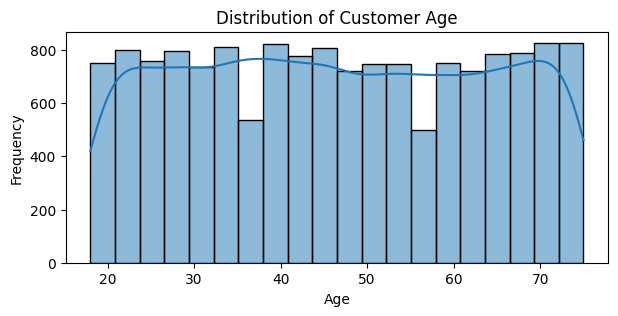

In [2]:
# distribution of customer age

plt.figure(figsize=(7, 3))
sns.histplot(df['customer_age'], bins=20, kde=True)
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

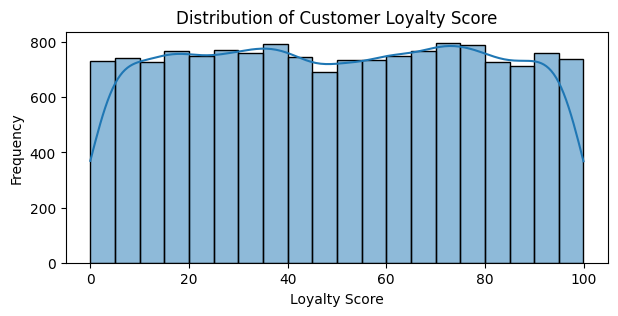

In [3]:
# distribution of customer loyalty score
plt.figure(figsize=(7, 3))
sns.histplot(df['customer_loyalty_score'], bins=20, kde=True)
plt.title('Distribution of Customer Loyalty Score')
plt.xlabel('Loyalty Score')
plt.ylabel('Frequency')
plt.show()

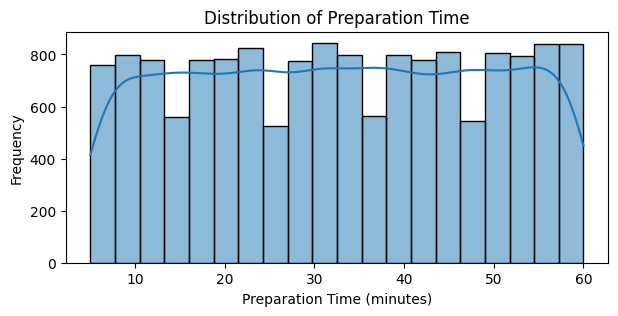

In [4]:
# distribution of preparation time
plt.figure(figsize=(7, 3))
sns.histplot(df['preparation_time_minutes'], bins=20, kde=True)
plt.title('Distribution of Preparation Time')
plt.xlabel('Preparation Time (minutes)')
plt.ylabel('Frequency')
plt.show()

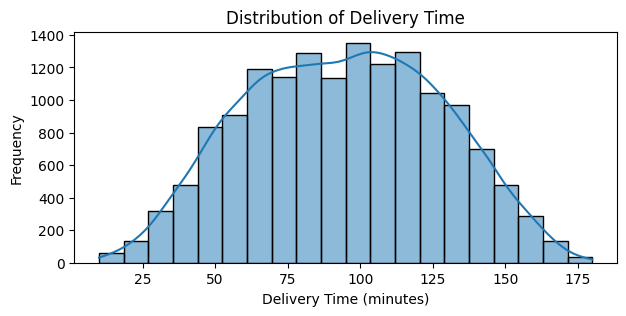

In [5]:
# distribution of delivery time
plt.figure(figsize=(7, 3))
sns.histplot(df['delivery_time_minutes'], bins=20, kde=True)
plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Frequency')
plt.show()

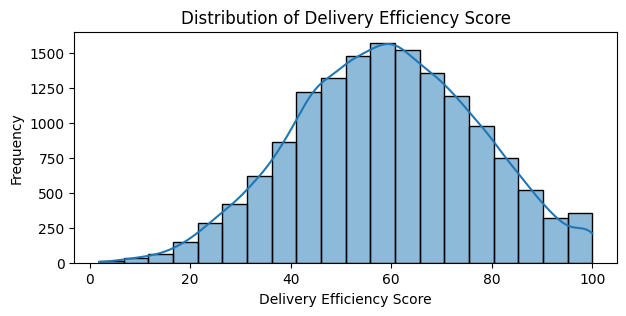

In [6]:
# distribution of delivery efficiency score
plt.figure(figsize=(7, 3))
sns.histplot(df['delivery_efficiency_score'], bins=20, kde=True)
plt.title('Distribution of Delivery Efficiency Score')
plt.xlabel('Delivery Efficiency Score')
plt.ylabel('Frequency')
plt.show()

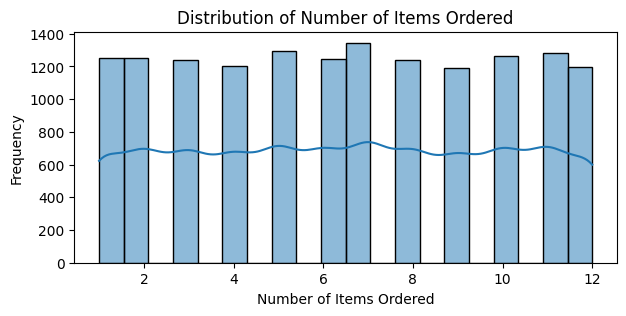

In [7]:
# distribution of number of items ordered
plt.figure(figsize=(7, 3))
sns.histplot(df['number_of_items'], bins=20, kde=True)
plt.title('Distribution of Number of Items Ordered')
plt.xlabel('Number of Items Ordered')
plt.ylabel('Frequency')
plt.show()

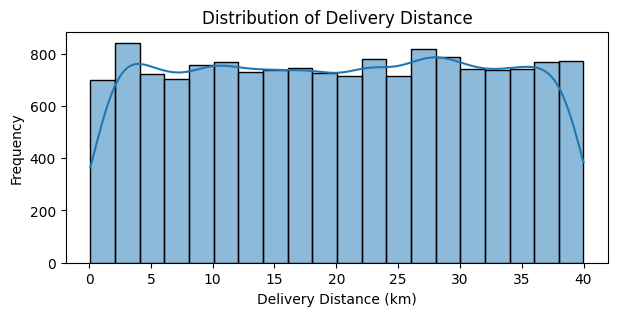

In [8]:
# distribution of delivery distance
plt.figure(figsize=(7, 3))
sns.histplot(df['delivery_distance_km'], bins=20, kde=True)
plt.title('Distribution of Delivery Distance')
plt.xlabel('Delivery Distance (km)')
plt.ylabel('Frequency')
plt.show()

## Categorical Feature Distributions

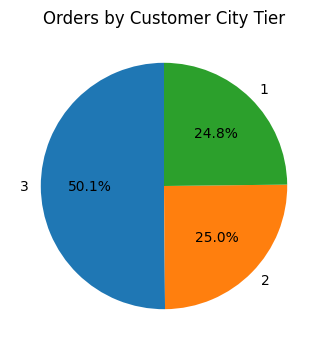

In [9]:
# orders by city tier
plt.figure(figsize=(6, 4))
df['city_tier'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Orders by Customer City Tier')
plt.show()

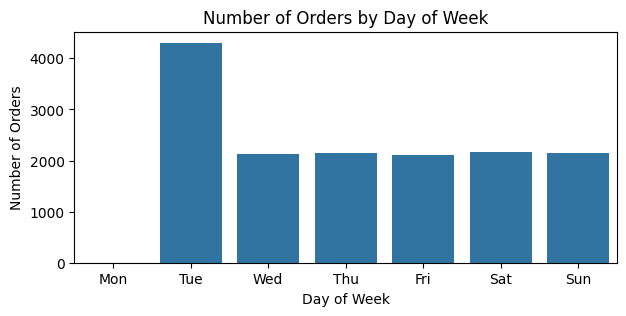

In [10]:
# ensure all days exist (0–6)
order_counts = df['order_day_of_week'].value_counts().reindex(range(7), fill_value=0)

labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

plt.figure(figsize=(7,3))
sns.barplot(x=labels, y=order_counts.values)

plt.title('Number of Orders by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
plt.show()

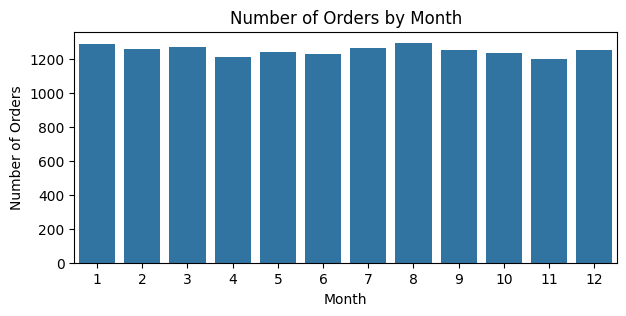

In [11]:
# orders by month
plt.figure(figsize=(7, 3))
sns.countplot(x='order_month', data=df)
plt.title('Number of Orders by Month')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.show()

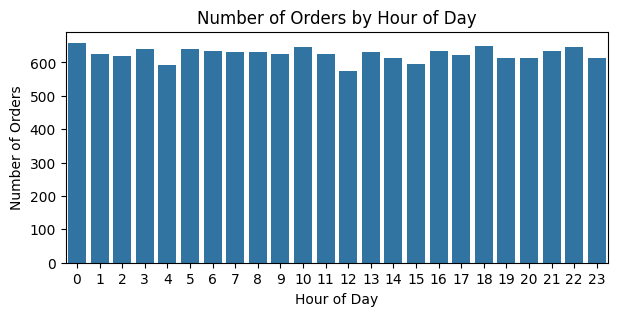

In [12]:
# order by hour
plt.figure(figsize=(7, 3))
sns.countplot(x='order_hour', data=df)  
plt.title('Number of Orders by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.show()

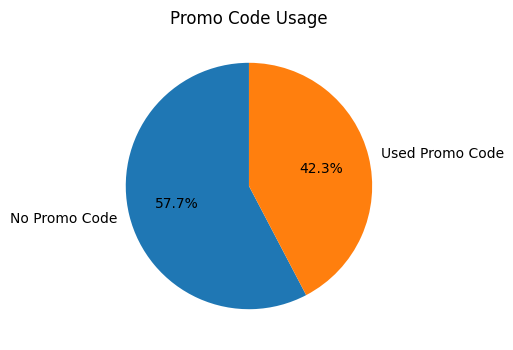

In [13]:
# promo code usage pie chart
plt.figure(figsize=(6, 4))
promo_counts = df['promo_code_used'].value_counts()
labels = ['No Promo Code', 'Used Promo Code']
plt.pie(promo_counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Promo Code Usage')
plt.show()

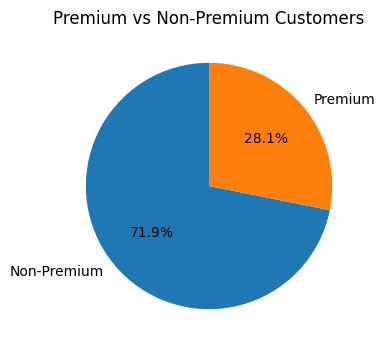

In [14]:
# premium vs non-premium customers
plt.figure(figsize=(6, 4))
premium_counts = df['premium_customer_flag'].value_counts()
labels = ['Non-Premium', 'Premium']
plt.pie(premium_counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Premium vs Non-Premium Customers')
plt.show()

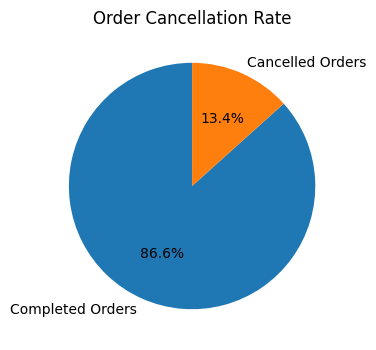

In [15]:
# cancellation rate
plt.figure(figsize=(6, 4))
cancellation_counts = df['cancellation_flag'].value_counts()
labels = ['Completed Orders', 'Cancelled Orders']
plt.pie(cancellation_counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Order Cancellation Rate')
plt.show()

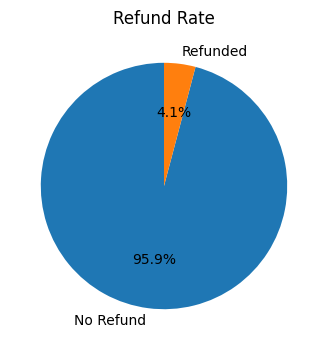

In [16]:
# refuned rate distribution
plt.figure(figsize=(6, 4))
refund_counts = df['refund_flag'].value_counts()
labels = ['No Refund', 'Refunded']
plt.pie(refund_counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Refund Rate')
plt.show()

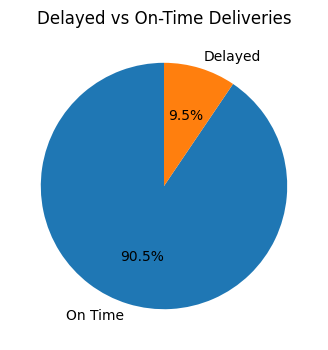

In [17]:
# delayed vs non-delayed orders
plt.figure(figsize=(6, 4))
delay_counts = df['delayed_delivery_flag'].value_counts()
labels = ['On Time', 'Delayed']
plt.pie(delay_counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Delayed vs On-Time Deliveries')
plt.show()

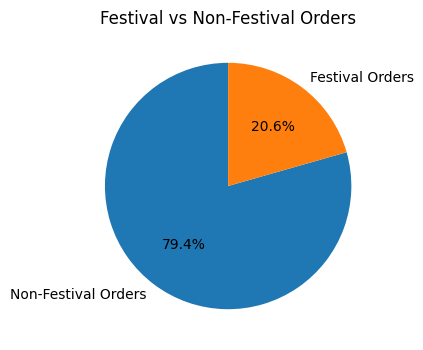

In [18]:
# festival or weekend vs non-festival orders
plt.figure(figsize=(6, 4))
festival_counts = df['festival_or_weekend_flag'].value_counts()
labels = ['Non-Festival Orders', 'Festival Orders']
plt.pie(festival_counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Festival vs Non-Festival Orders')
plt.show()

## Operational Performance Analysis

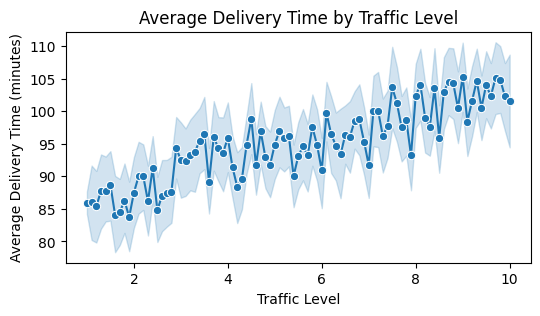

In [19]:
# average delivery time by traffic level
plt.figure(figsize=(6, 3))
sns.lineplot(x='traffic_level_score', y='delivery_time_minutes', data=df, marker='o')
plt.title('Average Delivery Time by Traffic Level')
plt.xlabel('Traffic Level')
plt.ylabel('Average Delivery Time (minutes)')
plt.show()

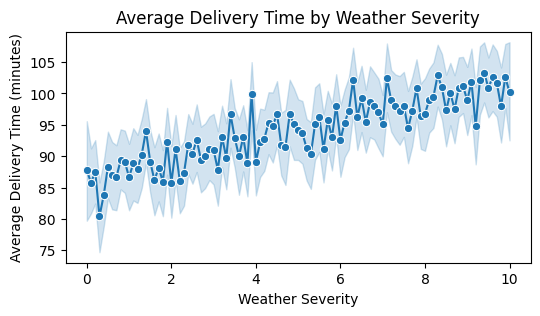

In [20]:
# average delivery time by weather severity
plt.figure(figsize=(6, 3))
sns.lineplot(x='weather_severity_score', y='delivery_time_minutes', data=df, marker='o')
plt.title('Average Delivery Time by Weather Severity')
plt.xlabel('Weather Severity')
plt.ylabel('Average Delivery Time (minutes)')
plt.show()

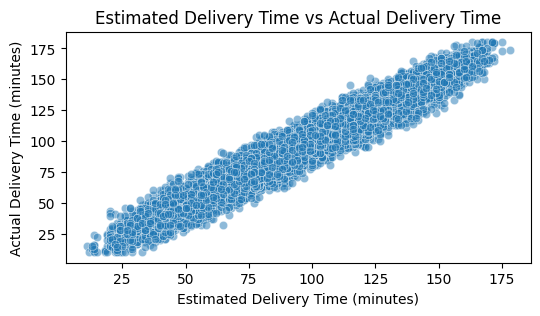

In [21]:
# estimated delivery time vs actual delivery time
plt.figure(figsize=(6, 3))
sns.scatterplot(x='estimated_delivery_time', y='delivery_time_minutes', data=df, alpha=0.5)
plt.title('Estimated Delivery Time vs Actual Delivery Time')
plt.xlabel('Estimated Delivery Time (minutes)')
plt.ylabel('Actual Delivery Time (minutes)')
plt.show()

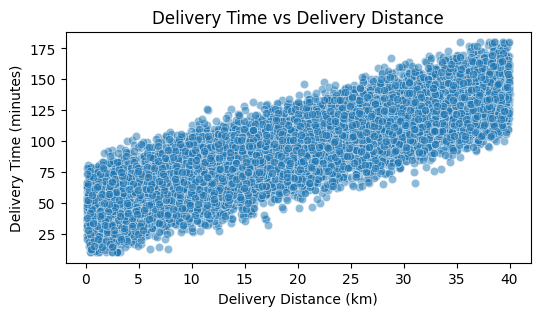

In [22]:
# delivery time vs delivery distance
plt.figure(figsize=(6, 3))
sns.scatterplot(x='delivery_distance_km', y='delivery_time_minutes', data=df, alpha=0.5)
plt.title('Delivery Time vs Delivery Distance')
plt.xlabel('Delivery Distance (km)')
plt.ylabel('Delivery Time (minutes)')
plt.show()

## Customer Behavior Analysis

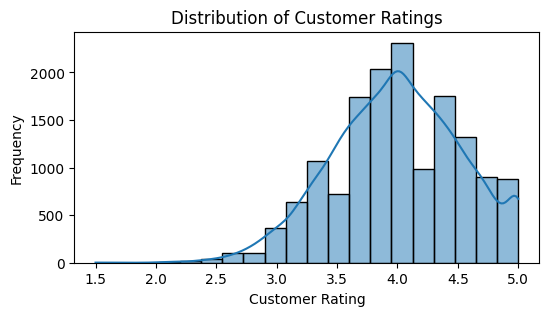

In [23]:
# customer rating distribution
plt.figure(figsize=(6, 3))
sns.histplot(df['customer_rating'], bins=20, kde=True)
plt.title('Distribution of Customer Ratings')
plt.xlabel('Customer Rating')
plt.ylabel('Frequency')
plt.show()

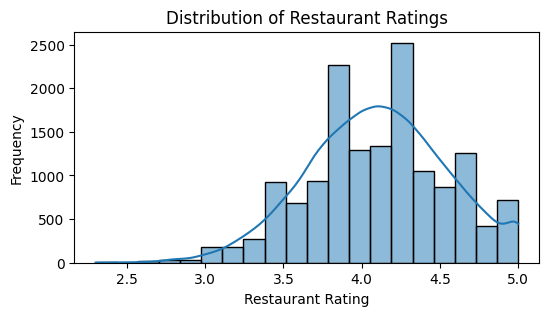

In [24]:
# restaurant rating distribution
plt.figure(figsize=(6, 3))
sns.histplot(df['restaurant_rating'], bins=20, kde=True)
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Restaurant Rating')
plt.ylabel('Frequency')
plt.show()

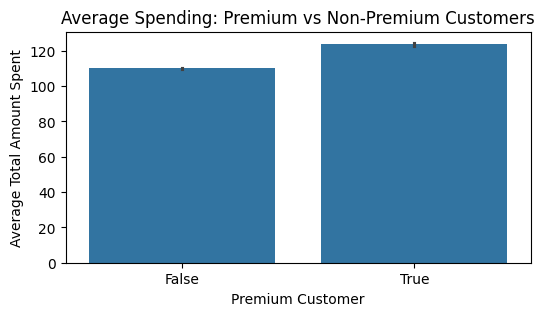

In [25]:
# premium customer vs average spending
plt.figure(figsize=(6, 3))
sns.barplot(x='premium_customer_flag', y='order_value', data=df)
plt.title('Average Spending: Premium vs Non-Premium Customers')
plt.xlabel('Premium Customer')
plt.ylabel('Average Total Amount Spent')
plt.show()

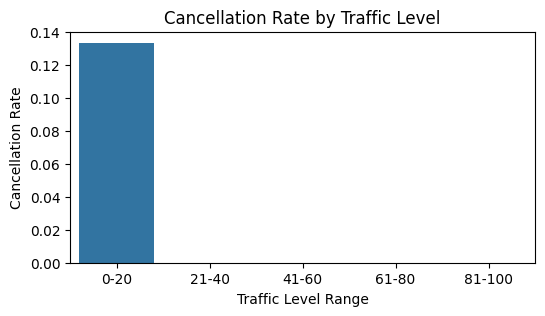

In [26]:
# create traffic level intervals
df['traffic_range'] = pd.cut(
    df['traffic_level_score'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=['0-20', '21-40', '41-60', '61-80', '81-100'],
    include_lowest=True
)

# average cancellation rate by traffic range
cancel_rate = (
    df.groupby('traffic_range', observed=True)['cancellation_flag']
    .mean()
    .reset_index()
)

# plot
plt.figure(figsize=(6, 3))

sns.barplot(
    x='traffic_range',
    y='cancellation_flag',
    data=cancel_rate
)

plt.title('Cancellation Rate by Traffic Level')
plt.xlabel('Traffic Level Range')
plt.ylabel('Cancellation Rate')

plt.show()

## Revenue & Financial Analysis

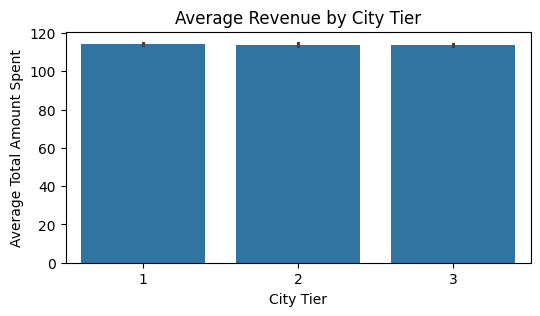

In [27]:
# revenue by city tier
plt.figure(figsize=(6, 3))
sns.barplot(x='city_tier', y='order_value', data=df)
plt.title('Average Revenue by City Tier')
plt.xlabel('City Tier')
plt.ylabel('Average Total Amount Spent')
plt.show()

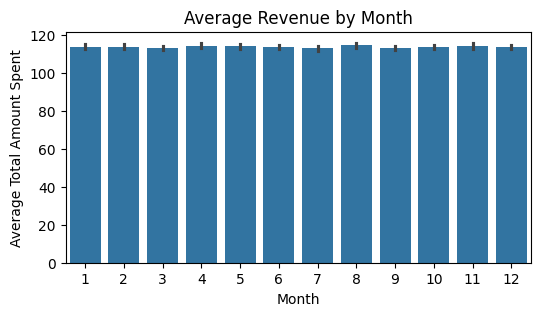

In [28]:
# revenue by month
plt.figure(figsize=(6, 3))
sns.barplot(x='order_month', y='order_value', data=df)
plt.title('Average Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Average Total Amount Spent')
plt.show()

## Correlation & Feature Relationships

<Figure size 600x300 with 0 Axes>

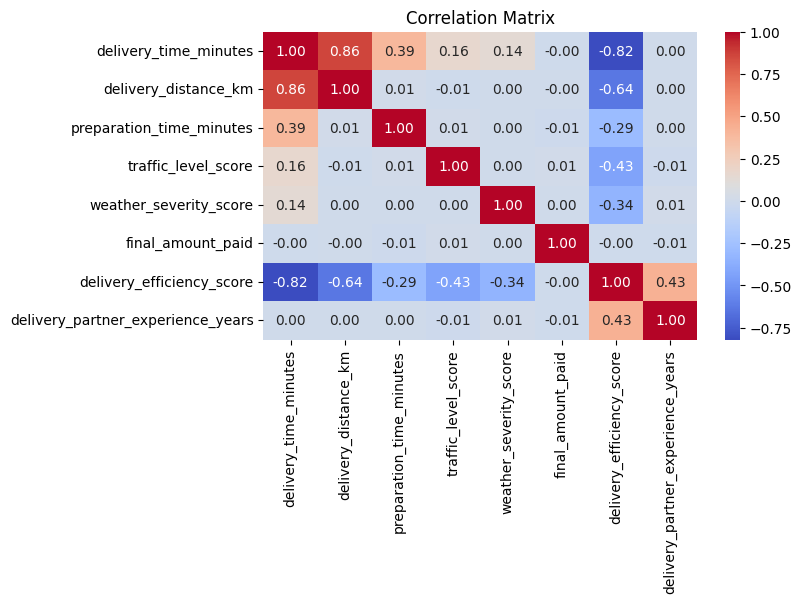

In [29]:
# correlation heatmap of numerical features
plt.figure(figsize=(6, 3))
corr_cols = ['delivery_time_minutes',
'delivery_distance_km',
'preparation_time_minutes',
'traffic_level_score',
'weather_severity_score',
'final_amount_paid',
'delivery_efficiency_score',
'delivery_partner_experience_years']


plt.figure(figsize=(7, 4))

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()